1. VERIFICAÇÃO DO BANCO DE DADOS

In [1]:
file.exists("/content/exportacao_cargas.csv.gz")

[1] TRUE

2. IMPORTAÇÃO DO BANCO DE DADOS

In [2]:
dados <- read.csv(
  "/content/exportacao_cargas.csv.gz",
  stringsAsFactors = FALSE,
  check.names = FALSE
)

3. VERIFICANDO SE O BANCO DE DADOS FOI IMPORTADO (LINHAS E COLUNAS)

In [3]:
dim(dados)

[1] 1097014      16

4. TRANSFORMANDO TOTAL_TONELADAS EM NÚMERO (TIRANDO A VÍRGUAL E COLOCANDO PONTO, (QUALITATIVA CONTÍNUA))

In [4]:
dados$TOTAL_TONELADAS <- as.numeric(
  gsub(",", ".", dados$TOTAL_TONELADAS)
)

5. CORREÇÃO DE VARIÁVEIS NUMÉRICAS (QUANTITATIVA DISCRETA)

In [5]:
dados$TOTAL_TEU <- as.integer(dados$TOTAL_TEU)
dados$TOTAL_UNID <- as.integer(dados$TOTAL_UNID)

6. CRIANDO SUBCONJUNTO PARA ANALISAR TOTAL_TEU PARA APENAS CARGA CONTERIZADA

In [6]:
dados_container <- dados[
  dados$NATUREZA_CARGA == "CARGA CONTEINERIZADA",
]

table(dados_container$NATUREZA_CARGA)
cat("\n")

dim(dados_container)


CARGA CONTEINERIZADA 
              978320 

[1] 978320     16

7. FAZENDO REGRESSÃO LINEAR SIMPLES

In [7]:
m <- lm(TOTAL_TONELADAS ~ TOTAL_TEU, data = dados_container)
summary(m)


Call:
lm(formula = TOTAL_TONELADAS ~ TOTAL_TEU, data = dados_container)

Residuals:
   Min     1Q Median     3Q    Max 
-40277   -117    -87     67  39613 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.206e+02  1.310e+00    92.1   <2e-16 ***
TOTAL_TEU   9.341e+00  5.657e-03  1651.4   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1210 on 978318 degrees of freedom
Multiple R-squared:  0.736,	Adjusted R-squared:  0.736 
F-statistic: 2.727e+06 on 1 and 978318 DF,  p-value: < 2.2e-16


8. GRÁFICO QUADRADO COM RETA AJUSTADA

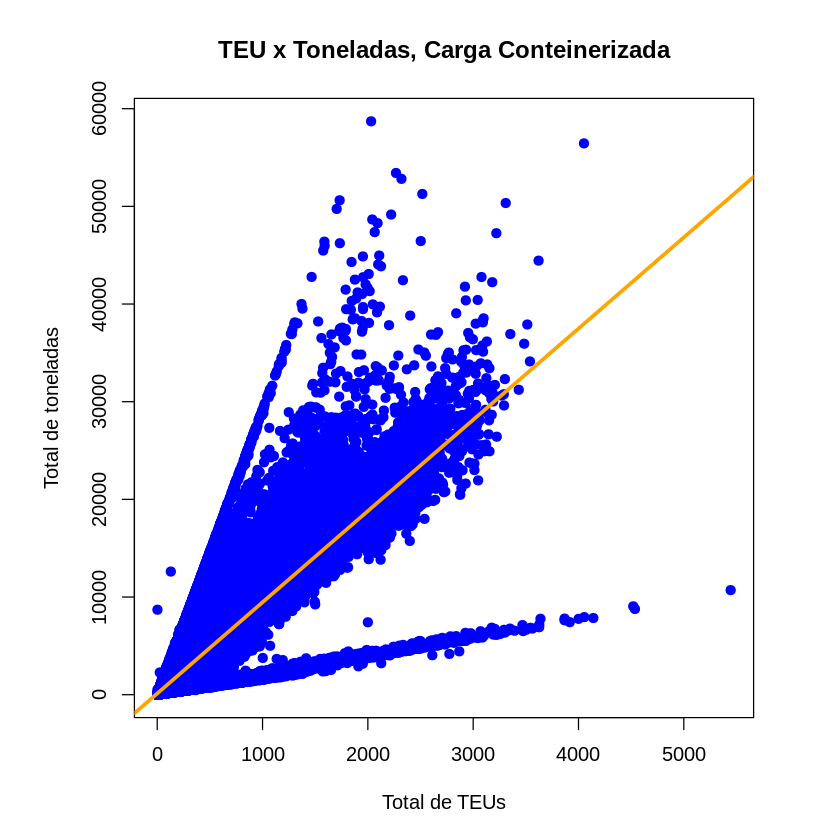

In [8]:
par(pty = "s")

plot(
  dados_container$TOTAL_TEU, dados_container$TOTAL_TONELADAS,
  pch = 19, col = "blue",
  main = "TEU x Toneladas, Carga Conteinerizada",
  xlab = "Total de TEUs", ylab = "Total de toneladas"
)

abline(m, col = "orange", lwd = 3)

9. FAZENDO REGRESSÃO LINEAR MÚLTIPLA

In [9]:
m2 <- lm(TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID, data = dados_container)
summary(m2)


Call:
lm(formula = TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID, data = dados_container)

Residuals:
   Min     1Q Median     3Q    Max 
-40137    -87    -60     72  28892 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 88.15772    1.27535   69.12   <2e-16 ***
TOTAL_TEU    1.61873    0.03101   52.20   <2e-16 ***
TOTAL_UNID  13.01724    0.05144  253.03   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1172 on 978317 degrees of freedom
Multiple R-squared:  0.7522,	Adjusted R-squared:  0.7522 
F-statistic: 1.485e+06 on 2 and 978317 DF,  p-value: < 2.2e-16


10. DIAGNÓSTICO DOS RESÍDUOS

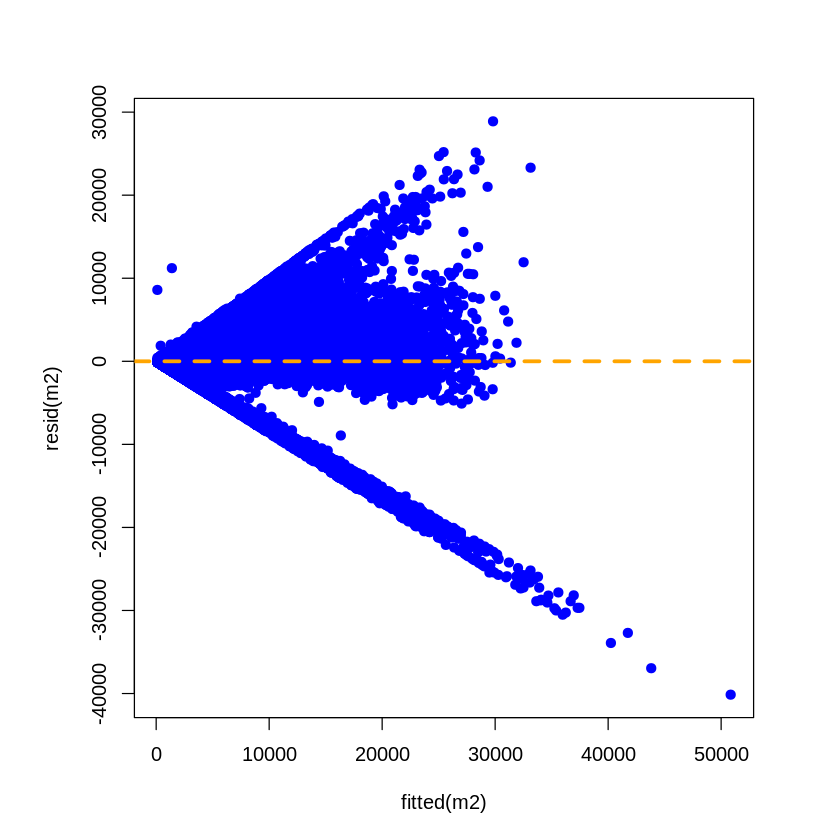

In [10]:
par(pty = "s")

plot(fitted(m2), resid(m2), pch = 19, col = "blue")
abline(h = 0, col = "orange", lwd = 3, lty = 2)

11. APLICANDO LOG

12. TRANSFORMAÇÃO

In [11]:
dados_container$log_TEU <- log(dados_container$TOTAL_TEU)
dados_container$log_TONELADAS <- log(dados_container$TOTAL_TONELADAS)

13. REGRESSÃO COM VARIÁVEIS EM LOG

In [12]:
m_log <- lm(log_TONELADAS ~ log_TEU, data = dados_container)
summary(m_log)  # b0, b1, p-valor, R²


Call:
lm(formula = log_TONELADAS ~ log_TEU, data = dados_container)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5459 -0.1826  0.2439  0.4993  5.7475 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.6925797  0.0013099    2056   <2e-16 ***
log_TEU     0.9103421  0.0004052    2247   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7445 on 978318 degrees of freedom
Multiple R-squared:  0.8377,	Adjusted R-squared:  0.8377 
F-statistic: 5.048e+06 on 1 and 978318 DF,  p-value: < 2.2e-16


14. GRÁFICO QUADRADO COM RETA EM LOG

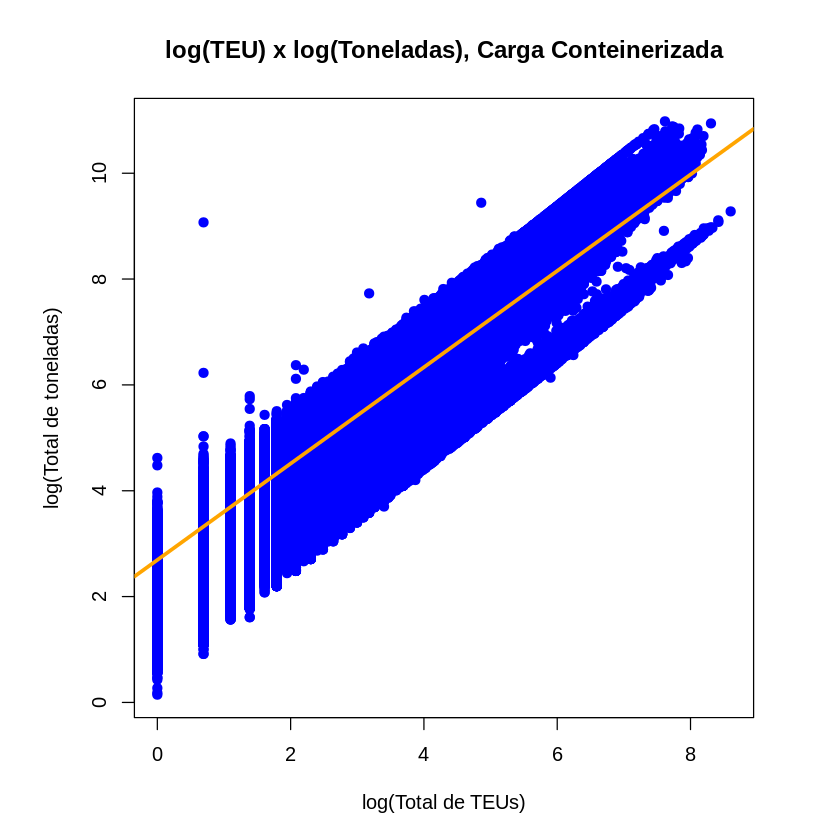

In [13]:
par(pty = "s")

plot(
  dados_container$log_TEU, dados_container$log_TONELADAS,
  pch = 19, col = "blue",
  main = "log(TEU) x log(Toneladas), Carga Conteinerizada",
  xlab = "log(Total de TEUs)", ylab = "log(Total de toneladas)"
)

abline(m_log, col = "orange", lwd = 3)

15. DIAGNÓSTICO COM RESÍDUOS EM LOG

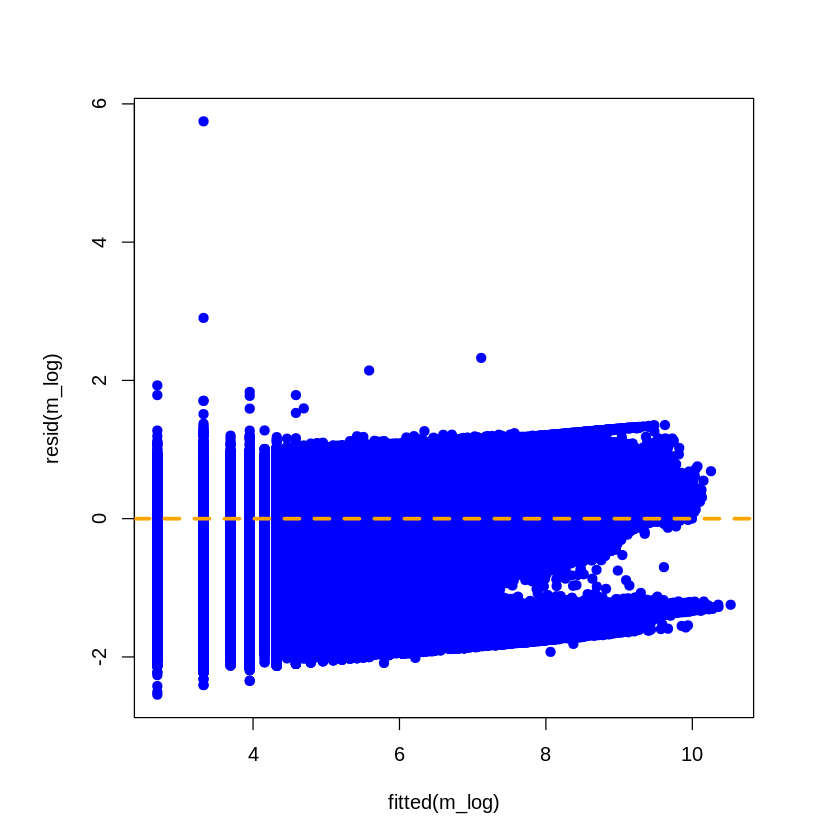

In [14]:
par(pty = "s")

plot(fitted(m_log), resid(m_log), pch = 19, col = "blue")
abline(h = 0, col = "orange", lwd = 3, lty = 2)

16. COMPARANDO O R² DOS DOIS MODELOS

In [15]:
cat("R² modelo original:", summary(m)$r.squared, "\n")
cat("R² modelo em log:", summary(m_log)$r.squared, "\n")

R² modelo original: 0.7359829 
R² modelo em log: 0.8376624 
